# Turismo no Brasil (2015-2024): análise e visualização de dados

Projeto G1 da disciplina Linguagem de Programação: Análise e Visualização de Dados com Python.

# 1. Introdução e contextualização

O turismo movimenta serviços, empregos e receita nas cidades. Este projeto analisa uma base **simulada** com registros mensais de 37 cidades brasileiras entre 2015 e 2024.

Perguntas que o notebook responde:
- O fluxo de turistas e o faturamento cresceram, caíram ou ficaram estáveis?
- Quais regiões e cidades concentram o fluxo e a receita?
- Existe alta temporada?
- Ocupação hoteleira, gasto médio, eventos e temperatura se relacionam com o faturamento?

# 2. Explicação da base

Arquivo: `dados/simulacao_turismo_brasil.csv`. Cada linha é uma cidade em um mês.

| Coluna | Descrição |
|---|---|
| ano, mes, data | Período do registro |
| regiao, uf, cidade | Localização |
| turistas | Total de turistas no mês |
| turistas_estrangeiros | Turistas estrangeiros no mês |
| ocupacao_hoteleira | Ocupação média dos hotéis (%) |
| gasto_medio | Gasto médio por turista (R$) |
| faturamento_turismo | Faturamento do turismo no mês (R$) |
| eventos_realizados | Número de eventos |
| temperatura_media | Temperatura média (°C) |
| nivel_temporada | Baixa, Média ou Alta (classificação da própria base) |

# 3. Leitura da base de dados

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine

sns.set_theme(style="whitegrid")
COR = "#2a9d8f"
COR_DESTAQUE = "#e76f51"

Path("../imagens").mkdir(exist_ok=True)

df = pd.read_csv("../dados/simulacao_turismo_brasil.csv")
print(df.shape)
df.head()

(4440, 14)


,ano,mes,data,regiao,uf,cidade,turistas,turistas_estrangeiros,ocupacao_hoteleira,gasto_medio,faturamento_turismo,eventos_realizados,temperatura_media,nivel_temporada
0,2015,1,2015-01-01,Norte,AM,Manaus,233689,47282,68.73,696.92,6.122438e+06,6,25.8,Média
1,2015,1,2015-01-01,Norte,PA,Belém,40837,41637,90.38,806.78,1.221923e+08,9,29.9,Baixa
2,2015,1,2015-01-01,Norte,PA,Santarém,393947,72315,89.25,1073.61,2.102537e+07,7,21.9,Baixa
3,2015,1,2015-01-01,Norte,RO,Porto Velho,278109,30614,91.51,237.15,7.601133e+07,8,25.5,Alta
4,2015,1,2015-01-01,Norte,TO,Palmas,282562,73139,76.32,791.34,1.663292e+08,5,28.6,Alta


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ano                    4440 non-null   int64  
 1   mes                    4440 non-null   int64  
 2   data                   4440 non-null   object 
 3   regiao                 4440 non-null   object 
 4   uf                     4440 non-null   object 
 5   cidade                 4440 non-null   object 
 6   turistas               4440 non-null   int64  
 7   turistas_estrangeiros  4440 non-null   int64  
 8   ocupacao_hoteleira     4440 non-null   float64
 9   gasto_medio            4440 non-null   float64
 10  faturamento_turismo    4440 non-null   float64
 11  eventos_realizados     4440 non-null   int64  
 12  temperatura_media      4440 non-null   float64
 13  nivel_temporada        4440 non-null   object 
dtypes: float64(4), int64(5), object(5)
memory usage: 485.8+ 

In [3]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
ano,4440.0,2019.50,2.87,2015.00,2017.00,2019.50,2.022000e+03,2.024000e+03
mes,4440.0,6.50,3.45,1.00,3.75,6.50,9.250000e+00,1.200000e+01
turistas,4440.0,256749.77,142686.32,10053.00,134104.25,258585.00,3.800922e+05,4.998960e+05
turistas_estrangeiros,4440.0,39943.76,22775.08,1022.00,20489.25,39543.50,5.973425e+04,7.994600e+04
ocupacao_hoteleira,4440.0,60.43,20.35,25.01,42.82,60.82,7.838000e+01,9.499000e+01
gasto_medio,4440.0,675.71,306.27,150.01,410.58,676.88,9.404100e+02,1.199800e+03
faturamento_turismo,4440.0,99825528.05,57263559.55,1026092.86,50487296.31,98628920.82,1.505042e+08,1.999846e+08
eventos_realizados,4440.0,9.91,3.10,1.00,8.00,10.00,1.200000e+01,2.300000e+01
temperatura_media,4440.0,24.90,4.02,9.20,22.20,24.90,2.760000e+01,4.030000e+01


# 4. Limpeza e preparação

In [4]:
print("Valores nulos:", df.isna().sum().sum())
print("Linhas duplicadas:", df.duplicated().sum())
print("Cidades:", df["cidade"].nunique(), "| Meses:", df["data"].nunique())

# Limpeza
df = df.drop_duplicates().dropna()
df["data"] = pd.to_datetime(df["data"])
for coluna in ["regiao", "uf", "cidade", "nivel_temporada"]:
    df[coluna] = df[coluna].str.strip()

Valores nulos: 0
Linhas duplicadas: 0
Cidades: 37 | Meses: 120


In [5]:
inconsistentes = df[df["turistas_estrangeiros"] > df["turistas"]]
print("Registros com turistas estrangeiros maiores que turistas totais:", len(inconsistentes))
inconsistentes[["cidade", "data", "turistas", "turistas_estrangeiros"]].head()

Registros com turistas estrangeiros maiores que turistas totais: 260


,cidade,data,turistas,turistas_estrangeiros
1,Belém,2015-01-01,40837,41637
28,Vitória,2015-01-01,13628,45268
67,Serra,2015-02-01,37463,67530
114,Porto Velho,2015-04-01,30159,43090
116,Salvador,2015-04-01,27166,46941


**Interpretação:** a base não tem nulos nem duplicados (4.440 linhas = 37 cidades x 120 meses). Porém 260 registros têm mais turistas estrangeiros do que turistas totais, o que é impossível. A coluna original será mantida e os indicadores usarão uma versão ajustada, limitada ao total de turistas.

# 5. Engenharia de atributos

In [6]:
NOMES_MESES = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun", "Jul", "Ago", "Set", "Out", "Nov", "Dez"]

# Variáveis derivadas
df["ano_mes"] = df["data"].dt.to_period("M").dt.to_timestamp()
df["nome_mes"] = df["mes"].apply(lambda m: NOMES_MESES[m - 1])
df["turistas_estrangeiros_ajustado"] = df[["turistas", "turistas_estrangeiros"]].min(axis=1)
df["pct_estrangeiros"] = df["turistas_estrangeiros_ajustado"] / df["turistas"] * 100
df["receita_por_turista"] = df["faturamento_turismo"] / df["turistas"]

df[["cidade", "ano_mes", "nome_mes", "turistas_estrangeiros_ajustado", "pct_estrangeiros", "receita_por_turista"]].head()

,cidade,ano_mes,nome_mes,turistas_estrangeiros_ajustado,pct_estrangeiros,receita_por_turista
0,Manaus,2015-01-01,Jan,47282,20.232874,26.199083
1,Belém,2015-01-01,Jan,40837,100.000000,2992.194731
2,Santarém,2015-01-01,Jan,72315,18.356530,53.371073
3,Porto Velho,2015-01-01,Jan,30614,11.007914,273.314899
4,Palmas,2015-01-01,Jan,73139,25.884231,588.646748


In [7]:
# Persistência no banco SQLite (SQLAlchemy)
Path("../database").mkdir(exist_ok=True)
engine = create_engine("sqlite:///../database/turismo_brasil.sqlite")
df.to_sql("turismo", engine, if_exists="replace", index=False)
pd.read_sql("SELECT COUNT(*) AS linhas FROM turismo", engine)

,linhas
0,4440


**Interpretação:** foram criados o período mensal (`ano_mes`), o nome do mês, a coluna ajustada de estrangeiros, o percentual de estrangeiros e a receita por turista. A tabela tratada foi gravada em SQLite para reuso pelo dashboard e para consultas SQL.

# 6. Análise exploratória

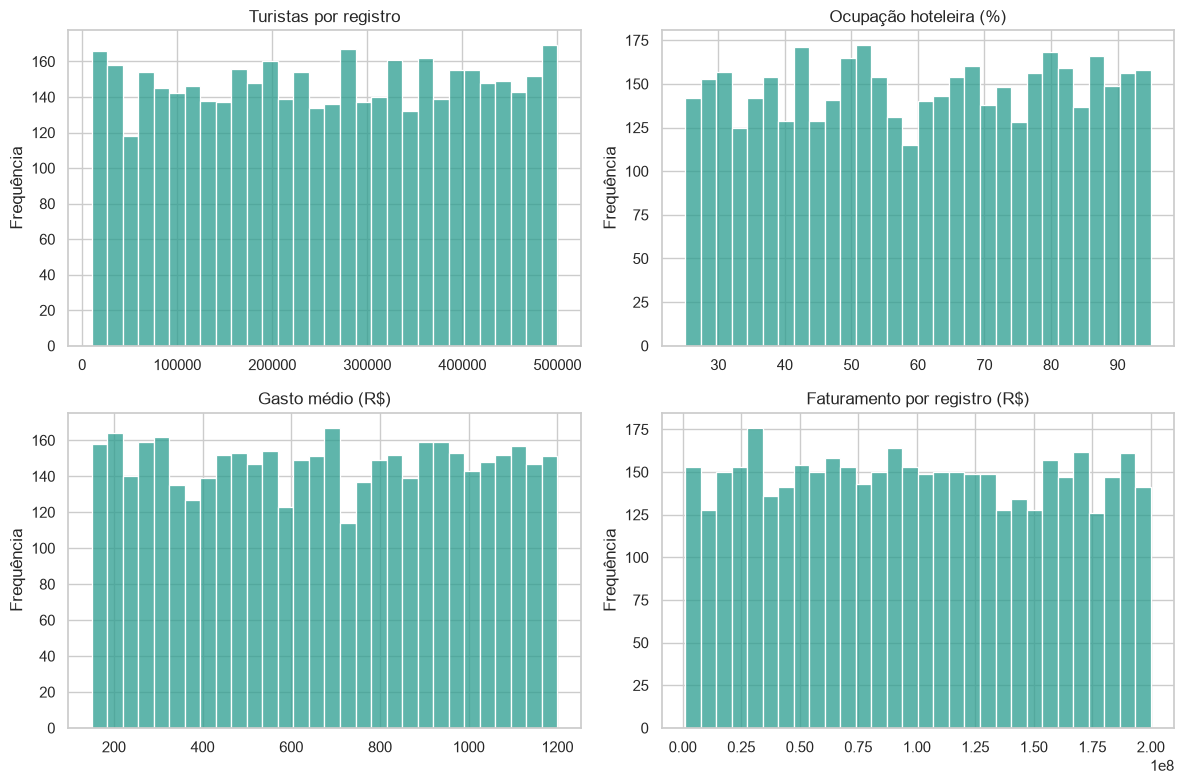

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, coluna, titulo in zip(
    axes.flatten(),
    ["turistas", "ocupacao_hoteleira", "gasto_medio", "faturamento_turismo"],
    ["Turistas por registro", "Ocupação hoteleira (%)", "Gasto médio (R$)", "Faturamento por registro (R$)"]
):
    sns.histplot(df[coluna], bins=30, color=COR, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel("Frequência")
plt.tight_layout()
plt.savefig("../imagens/distribuicoes.png")
plt.show()

**Interpretação:** as quatro variáveis têm distribuição aproximadamente uniforme, sem concentração em torno de uma média. Isso é típico de dados gerados por sorteio e difere de dados reais de turismo.

## 6.1 Evolução anual

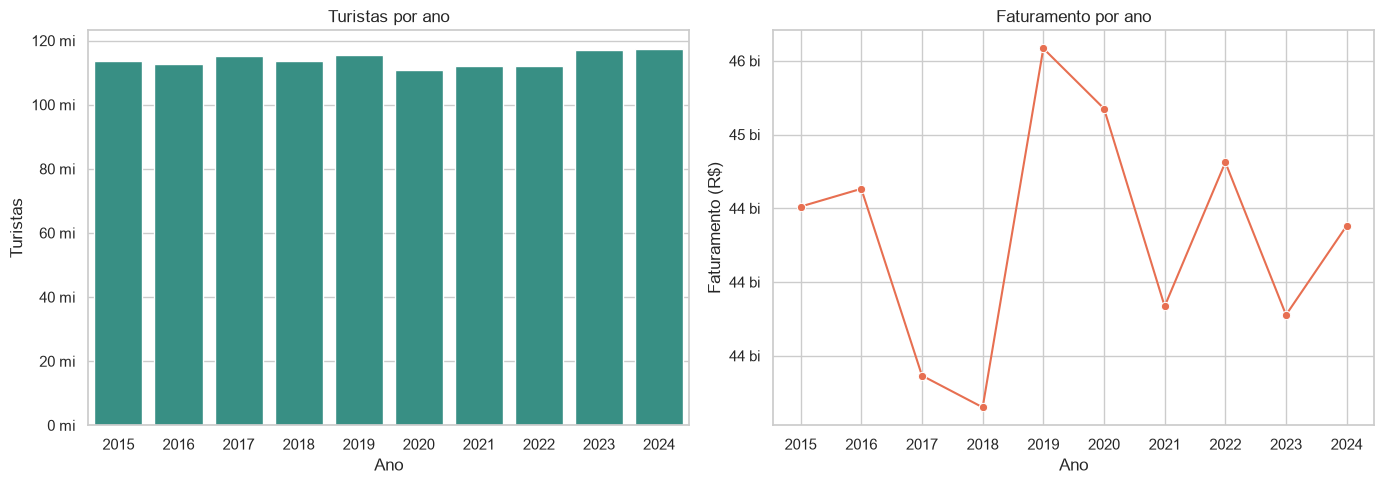

Variação de turistas 2015-2024: 3.3%
Variação em 2020: -4.0%


In [9]:
resumo_ano = (
    df.groupby("ano")
    .agg(turistas=("turistas", "sum"), faturamento=("faturamento_turismo", "sum"))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=resumo_ano, x="ano", y="turistas", color=COR, ax=axes[0])
axes[0].set_title("Turistas por ano")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Turistas")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"{v / 1e6:.0f} mi"))

sns.lineplot(data=resumo_ano, x="ano", y="faturamento", marker="o", color=COR_DESTAQUE, ax=axes[1])
axes[1].set_title("Faturamento por ano")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Faturamento (R$)")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"{v / 1e9:.0f} bi"))
axes[1].set_xticks(resumo_ano["ano"])
plt.tight_layout()
plt.savefig("../imagens/evolucao_anual.png")
plt.show()

turistas_ano = resumo_ano.set_index("ano")["turistas"]
print(f"Variação de turistas 2015-2024: {(turistas_ano[2024] / turistas_ano[2015] - 1) * 100:.1f}%")
print(f"Variação em 2020: {(turistas_ano[2020] / turistas_ano[2019] - 1) * 100:.1f}%")

**Interpretação:** o fluxo é estável: cerca de +3% entre 2015 e 2024. Em 2020 a queda é de apenas 4%, sem o choque que a pandemia causou no turismo real, outro sinal de que a base é simulada.

## 6.2 Regiões, UFs e cidades

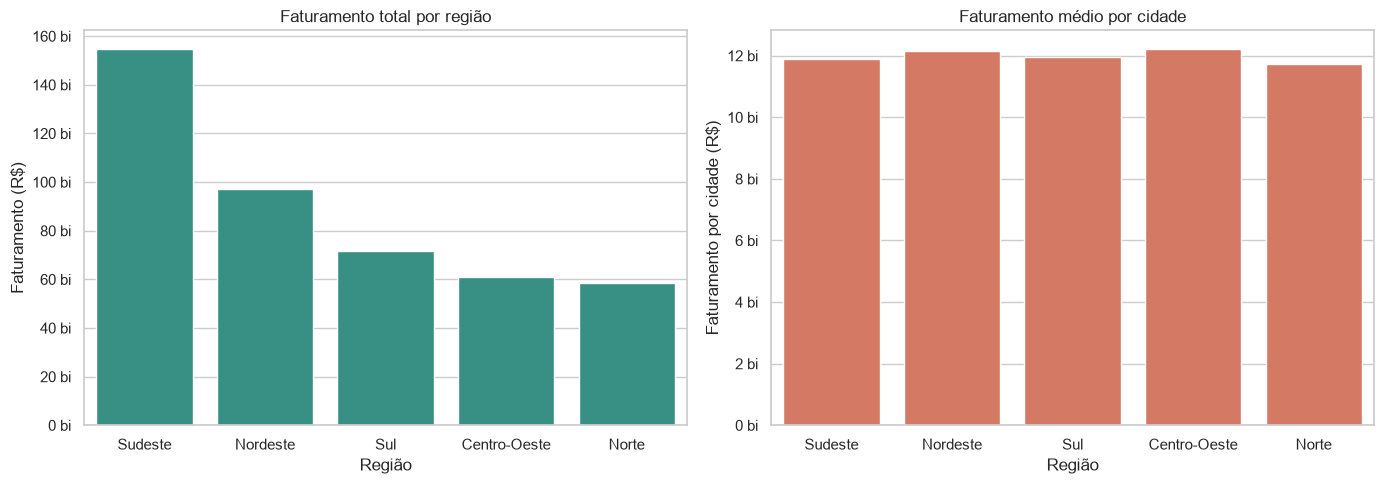

,regiao,faturamento,cidades,faturamento_por_cidade,participacao_pct
3,Sudeste,1.546133e+11,13,1.189333e+10,34.88
1,Nordeste,9.727251e+10,8,1.215906e+10,21.95
4,Sul,7.172694e+10,6,1.195449e+10,16.18
0,Centro-Oeste,6.103946e+10,5,1.220789e+10,13.77
2,Norte,5.857313e+10,5,1.171463e+10,13.22


In [10]:
resumo_regiao = (
    df.groupby("regiao")
    .agg(faturamento=("faturamento_turismo", "sum"), cidades=("cidade", "nunique"))
    .reset_index()
)
resumo_regiao["faturamento_por_cidade"] = resumo_regiao["faturamento"] / resumo_regiao["cidades"]
resumo_regiao["participacao_pct"] = resumo_regiao["faturamento"] / resumo_regiao["faturamento"].sum() * 100
resumo_regiao = resumo_regiao.sort_values("faturamento", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=resumo_regiao, x="regiao", y="faturamento", color=COR, ax=axes[0])
axes[0].set_title("Faturamento total por região")
axes[0].set_xlabel("Região")
axes[0].set_ylabel("Faturamento (R$)")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"{v / 1e9:.0f} bi"))

sns.barplot(data=resumo_regiao, x="regiao", y="faturamento_por_cidade", color=COR_DESTAQUE, ax=axes[1])
axes[1].set_title("Faturamento médio por cidade")
axes[1].set_xlabel("Região")
axes[1].set_ylabel("Faturamento por cidade (R$)")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"{v / 1e9:.0f} bi"))
plt.tight_layout()
plt.savefig("../imagens/regioes.png")
plt.show()

resumo_regiao.round(2)

**Interpretação:** o Sudeste lidera o faturamento total (cerca de 35%) porque reúne 13 das 37 cidades. Na média por cidade as regiões ficam muito próximas, então a liderança vem do número de cidades, não de um desempenho superior.

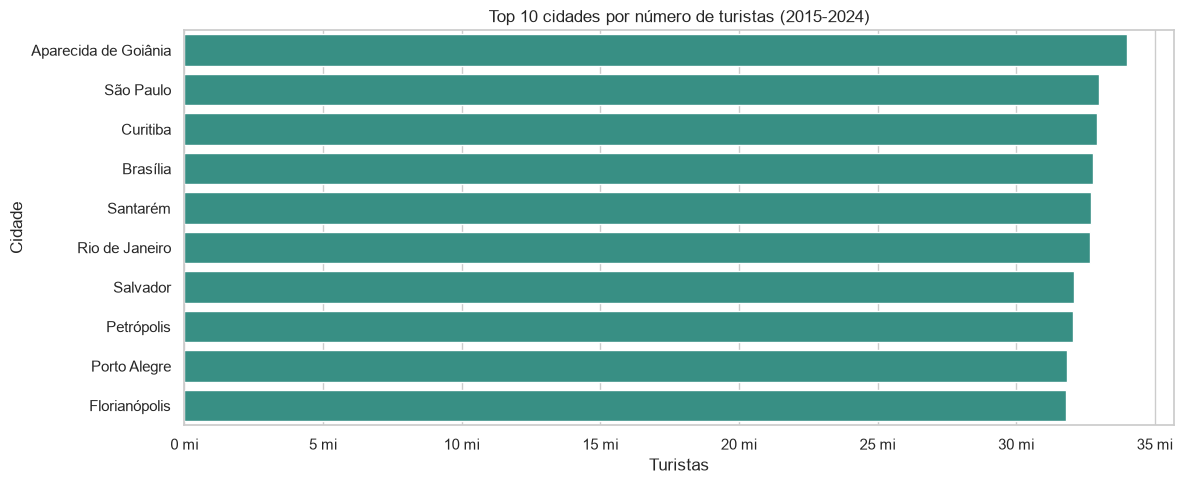

In [11]:
ranking_cidades = (
    df.groupby("cidade")["turistas"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=ranking_cidades, x="turistas", y="cidade", color=COR, ax=ax)
ax.set_title("Top 10 cidades por número de turistas (2015-2024)")
ax.set_xlabel("Turistas")
ax.set_ylabel("Cidade")
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"{v / 1e6:.0f} mi"))
plt.tight_layout()
plt.savefig("../imagens/ranking_cidades.png")
plt.show()

**Interpretação:** os totais das cidades do topo são muito próximos (diferenças de poucos pontos percentuais). Não há uma cidade dominante.

## 6.3 Sazonalidade

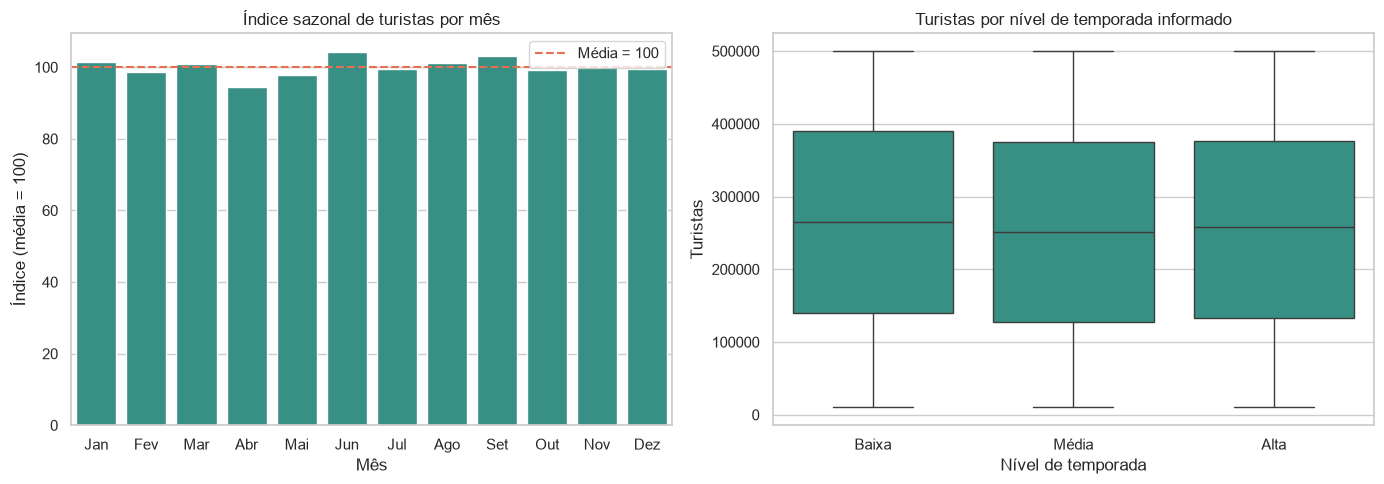

Índice mínimo: 94.5 | máximo: 104.2


In [12]:
media_mensal = (
    df.groupby(["mes", "nome_mes"])["turistas"]
    .mean()
    .reset_index()
)
media_mensal["indice_sazonal"] = media_mensal["turistas"] / media_mensal["turistas"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=media_mensal, x="nome_mes", y="indice_sazonal", color=COR, ax=axes[0])
axes[0].axhline(100, color=COR_DESTAQUE, linestyle="--", label="Média = 100")
axes[0].set_title("Índice sazonal de turistas por mês")
axes[0].set_xlabel("Mês")
axes[0].set_ylabel("Índice (média = 100)")
axes[0].legend()

sns.boxplot(data=df, x="nivel_temporada", y="turistas", order=["Baixa", "Média", "Alta"], color=COR, ax=axes[1])
axes[1].set_title("Turistas por nível de temporada informado")
axes[1].set_xlabel("Nível de temporada")
axes[1].set_ylabel("Turistas")
plt.tight_layout()
plt.savefig("../imagens/sazonalidade.png")
plt.show()

print("Índice mínimo:", media_mensal["indice_sazonal"].min().round(1), "| máximo:", media_mensal["indice_sazonal"].max().round(1))

**Interpretação:** o índice sazonal varia entre 94 e 104, uma amplitude pequena. Não existe alta temporada definida, e a coluna `nivel_temporada` não separa meses de maior ou menor fluxo (as caixas são praticamente iguais).

## 6.4 Série temporal com média móvel

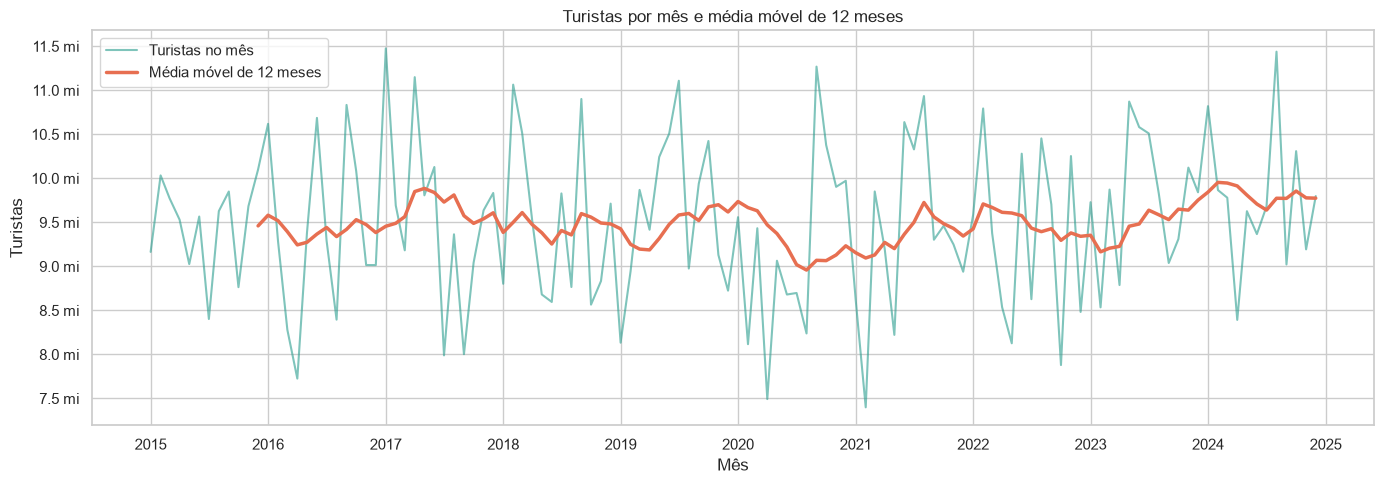

In [13]:
serie = (
    df.groupby("ano_mes")["turistas"]
    .sum()
    .reset_index()
    .sort_values("ano_mes")
)
serie["media_movel_12m"] = serie["turistas"].rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=serie, x="ano_mes", y="turistas", color=COR, alpha=0.6, label="Turistas no mês", ax=ax)
sns.lineplot(data=serie, x="ano_mes", y="media_movel_12m", color=COR_DESTAQUE, linewidth=2.5, label="Média móvel de 12 meses", ax=ax)
ax.set_title("Turistas por mês e média móvel de 12 meses")
ax.set_xlabel("Mês")
ax.set_ylabel("Turistas")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, p: f"{v / 1e6:.1f} mi"))
plt.tight_layout()
plt.savefig("../imagens/serie_temporal.png")
plt.show()

**Interpretação:** a média móvel de 12 meses é quase horizontal. Os picos e vales mensais são ruído, sem tendência de alta ou baixa no período.

# 7. KPIs

In [14]:
total_turistas = df["turistas"].sum()
total_faturamento = df["faturamento_turismo"].sum()
gasto_ponderado = (df["turistas"] * df["gasto_medio"]).sum() / total_turistas
ocupacao_media = df["ocupacao_hoteleira"].mean()
pct_estrangeiros = df["turistas_estrangeiros_ajustado"].sum() / total_turistas * 100

kpis = pd.DataFrame({
    "Indicador": ["Total de turistas", "Faturamento total (R$ bi)", "Gasto médio ponderado (R$)", "Ocupação hoteleira média (%)", "Turistas estrangeiros (%)"],
    "Valor": [f"{total_turistas:,.0f}".replace(",", "."), round(total_faturamento / 1e9, 2), round(gasto_ponderado, 2), round(ocupacao_media, 1), round(pct_estrangeiros, 1)]
})
kpis

,Indicador,Valor
0,Total de turistas,1.139.968.982
1,Faturamento total (R$ bi),443.23
2,Gasto médio ponderado (R$),678.05
3,Ocupação hoteleira média (%),60.4
4,Turistas estrangeiros (%),15.0


**Interpretação:** o gasto médio é ponderado pelo número de turistas (e não a média simples da coluna). O faturamento total é de cerca de R$ 443 bilhões, com ocupação média de 60% e 15% de turistas estrangeiros.

# 8. Gráficos de correlação

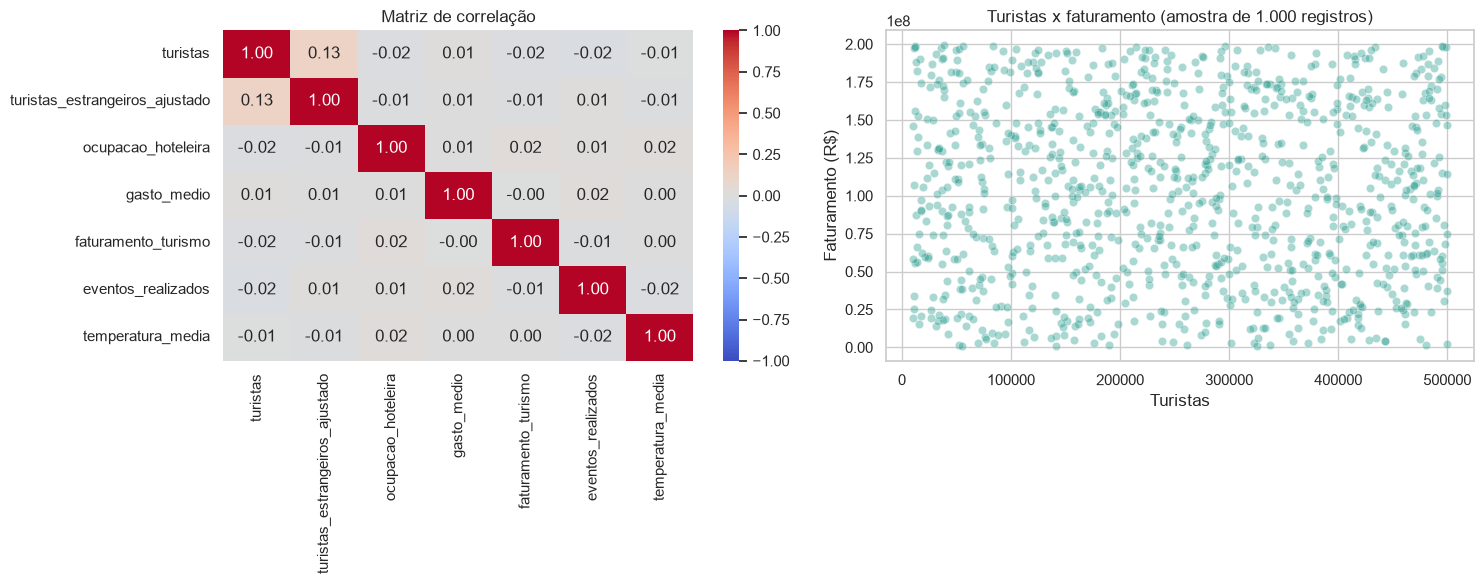

Razão (turistas x gasto médio) / faturamento:
count    4440.00
mean        4.77
std        15.02
min         0.01
25%         0.68
50%         1.59
75%         3.41
max       309.68
dtype: float64


In [15]:
colunas_corr = [
    "turistas", "turistas_estrangeiros_ajustado", "ocupacao_hoteleira", "gasto_medio",
    "faturamento_turismo", "eventos_realizados", "temperatura_media"
]
matriz_corr = df[colunas_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Matriz de correlação")

amostra = df.sample(1000, random_state=1)
sns.scatterplot(data=amostra, x="turistas", y="faturamento_turismo", alpha=0.4, color=COR, ax=axes[1])
axes[1].set_title("Turistas x faturamento (amostra de 1.000 registros)")
axes[1].set_xlabel("Turistas")
axes[1].set_ylabel("Faturamento (R$)")
plt.tight_layout()
plt.savefig("../imagens/correlacao.png")
plt.show()

print("Razão (turistas x gasto médio) / faturamento:")
print((df["turistas"] * df["gasto_medio"] / df["faturamento_turismo"]).describe().round(2))

**Interpretação:** as correlações ficam entre -0,03 e +0,03, ou seja, nenhuma variável explica o faturamento. Além disso, turistas x gasto médio não reproduz o faturamento: a razão varia de cerca de 0,01 a mais de 300. Cada coluna parece ter sido sorteada de forma independente.

# 9. Interpretação dos resultados

In [16]:
consulta = """
SELECT regiao,
       COUNT(DISTINCT cidade) AS cidades,
       ROUND(SUM(faturamento_turismo) / 1000000000.0, 2) AS faturamento_bi,
       ROUND(AVG(ocupacao_hoteleira), 1) AS ocupacao_media
FROM turismo
GROUP BY regiao
ORDER BY faturamento_bi DESC
"""
pd.read_sql(consulta, engine)

,regiao,cidades,faturamento_bi,ocupacao_media
0,Sudeste,13,154.61,60.4
1,Nordeste,8,97.27,59.9
2,Sul,6,71.73,60.8
3,Centro-Oeste,5,61.04,60.7
4,Norte,5,58.57,60.6


Principais achados:

1. **Fluxo estável:** variação de cerca de +3% de 2015 a 2024; 2020 cai só 4%.
2. **Sem alta temporada:** índice sazonal entre 94 e 104; `nivel_temporada` não se relaciona com o fluxo.
3. **Sudeste lidera por tamanho:** 13 das 37 cidades; por cidade, as regiões se equivalem.
4. **Sem correlações:** todas entre -0,03 e +0,03; o faturamento não bate com turistas x gasto médio.
5. **Qualidade dos dados:** 260 registros com estrangeiros acima do total foram ajustados.

# 10. Conclusão

A base simulada não mostra tendência, sazonalidade nem relações entre variáveis, o que é esperado para dados sorteados de forma independente. O trabalho cumpre o objetivo técnico: tratar a base, criar atributos e KPIs, persistir em SQLite, analisar séries temporais e correlações e publicar as visualizações em um dashboard interativo. Em dados reais de turismo seria esperado encontrar sazonalidade marcante, efeito da pandemia em 2020 e relação entre fluxo e receita.